# MultiRocket Improvements - Results Analysis

This notebook consolidates, analyses, and visualises all experimental results
from three independent improvement approaches applied to the MultiRocket time
series classification algorithm, as part of the COMP41850 AI for Time Series
project at University College Dublin.

**Paper reproduced:** MultiRocket: Multiple Pooling Operators and Transformations
for Fast and Effective Time Series Classification (Tan et al., 2022).

**Improvements evaluated:**
1. Fifth pooling operator - Variance and Skewness
2. Alternative classifier head - MLP and Random Forest
3. Reduced kernel size - 9 → 7

---

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
   - 1.1 Data Coverage Report
2. [Dataset Statistics](#2-dataset-statistics)
   - 2.1 Observations
3. [Results by Improvement](#3-results-by-improvement)
   - 3.1 Fifth Pooling Operator: Variance and Skewness
   - 3.2 Classifier Substitution: MLP and Random Forest
   - 3.3 Kernel Size Reduction: 9 → 7
4. [Extended Analysis](#4-extended-analysis)
   - 4.1 Synthesis and Conclusion

---

## 1. Setup and Data Loading

In [91]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import itertools

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.6f}'.format)

In [92]:
# --- Path configuration ---
OUTPUT_DIR = Path('../output')
SUPPLEMENTARY_CSV = Path('../temp_tests/final_rf_comparison_ready.csv')

# --- Classifier configuration ---
# MultiRocket_10000 is excluded; MultiRocket_49728 is the canonical baseline to ensure fair feature-count comparisons with the 49 728-feature variants.
EXCLUDED_CLASSIFIERS = frozenset({'MultiRocket_10000'})

CLASSIFIER_LABEL_MAP: dict[str, str] = {
    'MultiRocket_49728': 'Baseline',
    'rf_MultiRocket_49728': 'RF',
    'mlp_MultiRocket_49728': 'MLP',
    'skew_MultiRocket_62160': 'Skew',
    'var_MultiRocket_62160': 'Var',
    'ker7_MultiRocket_20720': 'Ker7',
}

# Ordered for consistent chart rendering
LABEL_ORDER: list[str] = ['Baseline', 'Var', 'Skew', 'MLP', 'RF', 'Ker7']

TARGET_DATASETS: list[str] = [
    'InsectWingbeatSound',
    'StarLightCurves',
    'ElectricDevices',
    'Crop',
]

# --- Timing components used to compute total_time ---
TIMING_COMPONENTS: list[str] = [
    'train_time',
    'test_time',
    'generate_kernel_time',
    'apply_kernel_on_train_time',
    'apply_kernel_on_test_time',
]

# --- Canonical unified column order ---
UNIFIED_COLUMNS: list[str] = [
    'source',
    'timestamp',
    'dataset',
    'classifier',
    'classifier_label',
    'num_features',
    'train_acc',
    'train_time',
    'test_acc',
    'test_time',
    'generate_kernel_time',
    'apply_kernel_on_train_time',
    'apply_kernel_on_test_time',
    'train_transform_time',
    'test_transform_time',
    'total_time',
]

In [93]:
class ResultsLoader:
    """Loads and unifies MultiRocket experiment results from multiple CSV sources.

    The output/ directory contains 19-column CSVs produced by shell runners.
    The supplementary CSV contains 8-column summaries for additional datasets not yet covered by the output/ runs.
    This class merges both sources into a single canonical DataFrame, resolving schema differences with NaN padding."""

    def __init__(
        self,
        output_dir: Path,
        supplementary_path: Path,
        label_map: dict[str, str],
        excluded_classifiers: frozenset,
        unified_columns: list[str],
        timing_components: list[str],
    ) -> None:
        self.output_dir = output_dir
        self.supplementary_path = supplementary_path
        self.label_map = label_map
        self.excluded_classifiers = excluded_classifiers
        self.unified_columns = unified_columns
        self.timing_components = timing_components

    # --- Private helpers ---

    def _load_output_csvs(self) -> pd.DataFrame:
        """Recursively reads all results CSVs from the output directory."""

        csv_paths = list(self.output_dir.rglob('*.csv'))
        assert csv_paths, f'No CSV files found under {self.output_dir}'

        frames = []
        for path in csv_paths:
            try:
                frame = pd.read_csv(path)
                frame['source'] = 'output'
                frames.append(frame)
            except Exception as exc:
                print(f'Warning: could not read {path} - {exc}')

        return pd.concat(frames, ignore_index=True)

    def _load_supplementary_csv(self) -> pd.DataFrame:
        """Reads the supplementary RF results CSV."""

        assert self.supplementary_path.exists(), (
            f'Supplementary CSV not found at {self.supplementary_path}'
        )
        frame = pd.read_csv(self.supplementary_path)
        frame['source'] = 'supplementary'
        return frame

    def _compute_total_time(self, df: pd.DataFrame) -> pd.DataFrame:
        """Computes total_time for rows where it is absent.

        For output/ rows, total_time is computed as the sum of all five timing components.
        For supplementary rows, total_time is already provided and is left unchanged."""

        if 'total_time' not in df.columns:
            df['total_time'] = np.nan

        missing_mask = df['total_time'].isna()
        available_components = [
            c for c in self.timing_components if c in df.columns
        ]
        df.loc[missing_mask, 'total_time'] = (
            df.loc[missing_mask, available_components]
            .sum(axis=1, min_count=1)
        )
        return df

    def _sanitise_train_acc(self, df: pd.DataFrame) -> pd.DataFrame:
        """Replaces sentinel value -1 in train_acc with NaN.

        The shell runners store -1 when training accuracy is not computed."""

        if 'train_acc' in df.columns:
            df['train_acc'] = df['train_acc'].replace(-1, np.nan)
        return df

    def _apply_labels_and_filter(self, df: pd.DataFrame) -> pd.DataFrame:
        """Removes excluded classifiers and maps raw names to human-readable labels."""

        df = df[~df['classifier'].isin(self.excluded_classifiers)].copy()
        df['classifier_label'] = df['classifier'].map(self.label_map)

        unmapped = df.loc[df['classifier_label'].isna(), 'classifier'].unique()
        if unmapped.size:
            print(f'Warning: the following classifiers are unmapped and will be excluded from analysis: {list(unmapped)}')
            df = df[df['classifier_label'].notna()]

        return df

    def _deduplicate(self, df: pd.DataFrame) -> pd.DataFrame:
        """Retains one row per (dataset, classifier) pair.

        When both output/ and supplementary rows exist for the same pair, the output/ row is preferred as it contains the fuller 19-column schema with kernel timing breakdowns."""
        
        # 'output' sorts before 'supplementary', so ascending sort + keep='first' guarantees output/ rows take precedence.
        df = df.sort_values('source', ascending=True)
        df = df.drop_duplicates(subset=['dataset', 'classifier'], keep='first')
        return df.reset_index(drop=True)

    def _enforce_unified_schema(self, df: pd.DataFrame) -> pd.DataFrame:
        """Reindexes to the canonical column list, inserting NaN for any absent columns."""

        for col in self.unified_columns:
            if col not in df.columns:
                df[col] = np.nan
        return df[self.unified_columns]

    # --- Public interface ---

    def load(self) -> pd.DataFrame:
        """Executes the full data loading and unification pipeline.

        Returns a clean DataFrame with unified schema, deduplicated rows, and a classifier_label column ready for downstream analysis."""

        output_df = self._load_output_csvs()
        supplementary_df = self._load_supplementary_csv()

        combined = pd.concat([output_df, supplementary_df], ignore_index=True)
        combined = self._sanitise_train_acc(combined)
        combined = self._compute_total_time(combined)
        combined = self._apply_labels_and_filter(combined)
        combined = self._deduplicate(combined)
        combined = self._enforce_unified_schema(combined)

        return combined.sort_values(
            ['dataset', 'classifier_label']
        ).reset_index(drop=True)

In [94]:
loader = ResultsLoader(
    output_dir=OUTPUT_DIR,
    supplementary_path=SUPPLEMENTARY_CSV,
    label_map=CLASSIFIER_LABEL_MAP,
    excluded_classifiers=EXCLUDED_CLASSIFIERS,
    unified_columns=UNIFIED_COLUMNS,
    timing_components=TIMING_COMPONENTS,
)

results_df = loader.load()
display(results_df)

,source,timestamp,dataset,classifier,classifier_label,num_features,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,total_time
0,supplementary,08/04/2026 14:21,Beef,rf_MultiRocket_49728,RF,49728,NaN,0.129914,0.766667,0.013208,NaN,NaN,NaN,NaN,NaN,0.315641
1,supplementary,08/04/2026 14:21,Coffee,rf_MultiRocket_49728,RF,49728,NaN,0.114910,1.000000,0.014215,NaN,NaN,NaN,NaN,NaN,0.240932
2,supplementary,08/04/2026 14:25,Crop,rf_MultiRocket_49728,RF,49728,NaN,31.137841,0.758571,7.421087,NaN,NaN,NaN,NaN,NaN,44.562995
3,supplementary,08/04/2026 14:21,ECG200,rf_MultiRocket_49728,RF,49728,NaN,0.180972,0.880000,0.015856,NaN,NaN,NaN,NaN,NaN,0.331832
4,supplementary,08/04/2026 14:23,ElectricDevices,rf_MultiRocket_49728,RF,49728,NaN,68.756335,0.726624,0.480663,NaN,NaN,NaN,NaN,NaN,75.208709
5,output,2026-03-31 15:38:45,InsectWingbeatSound,MultiRocket_49728,Baseline,49728,NaN,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,2.833681
6,output,2026-04-09 19:23:43,InsectWingbeatSound,ker7_MultiRocket_20720,Ker7,20720,NaN,1.355187,0.637879,0.145321,0.011803,0.049037,0.384341,0.000082,0.000585,1.945689
7,output,2026-04-01 19:57:16,InsectWingbeatSound,mlp_MultiRocket_49728,MLP,49728,NaN,2.418536,0.623737,0.215926,0.027849,0.097553,0.866504,0.000065,0.000422,3.626368
8,output,2026-04-09 17:40:23,InsectWingbeatSound,rf_MultiRocket_49728,RF,49728,NaN,0.358550,0.667172,0.037171,0.028402,0.100209,0.893050,0.000053,0.000793,1.417383
9,output,2026-04-01 17:20:28,InsectWingbeatSound,skew_MultiRocket_62160,Skew,62160,NaN,1.930530,0.618687,0.363790,0.028366,0.105219,0.988746,0.000148,0.000409,3.416651


### 1.1 Data Coverage Report

The following pivot table shows which (dataset, classifier) combinations have
results. A `✓` indicates a row is present in the unified DataFrame. Blank cells
indicate missing experiments, which charting functions must handle gracefully.

In [95]:
def build_coverage_report(df: pd.DataFrame, datasets: list[str], label_order: list[str]) -> pd.DataFrame:
    """Constructs a dataset × classifier coverage matrix.

    Each cell shows '✓' where data exists and the data source in parentheses, or is left blank where no results are available."""

    rows = []
    for dataset in datasets:
        row = {'Dataset': dataset}
        for label in label_order:
            match = df[
                (df['dataset'] == dataset) &
                (df['classifier_label'] == label)
            ]
            if match.empty:
                row[label] = ''
            else:
                source = match['source'].iloc[0]
                row[label] = f'✓ ({source})'
        rows.append(row)
    return pd.DataFrame(rows).set_index('Dataset')


coverage = build_coverage_report(results_df, TARGET_DATASETS, LABEL_ORDER)
print('Data coverage: ✓ = results present, blank = missing')
display(coverage)

# Summarise total_time completeness for downstream timing charts
timing_completeness = results_df.groupby('classifier_label')['total_time'].apply(
    lambda s: s.notna().sum()
).rename('rows_with_total_time')
print('\nTiming data completeness per classifier:')
display(timing_completeness.to_frame())

Data coverage: ✓ = results present, blank = missing


,Baseline,Var,Skew,MLP,RF,Ker7
Dataset,,,,,,
InsectWingbeatSound,✓ (output),✓ (output),✓ (output),✓ (output),✓ (output),✓ (output)
StarLightCurves,✓ (output),✓ (output),✓ (output),✓ (output),✓ (output),✓ (output)
ElectricDevices,,,,,✓ (supplementary),
Crop,,,,,✓ (supplementary),



Timing data completeness per classifier:


,rows_with_total_time
classifier_label,
Baseline,2
Ker7,2
MLP,2
RF,7
Skew,2
Var,2


---

## 2. Dataset Statistics

The four UCR archive datasets selected for evaluation span a broad range of
sizes, time series lengths, and class cardinalities. This section presents
their key properties as sourced from the repository README files and the
UCR 2018 archive metadata.

In [96]:
from dataclasses import dataclass

@dataclass(frozen=True)
class DatasetProfile:
    """Immutable record of a UCR time series classification dataset's properties."""

    name: str
    domain: str
    train_size: int
    test_size: int
    series_length: int
    num_classes: int
    has_missing_values: bool

    @property
    def total_size(self) -> int:
        """Returns the combined train and test instance count."""

        return self.train_size + self.test_size

    @property
    def train_test_ratio(self) -> float:
        """Returns the ratio of training to test instances."""
        
        return self.train_size / self.test_size


# --- Dataset metadata sourced from UCR archive README files ---
# Values verified against data/classification_datasets_109.csv (UCR 2018 IDs 37, 66, 23, 92 respectively).
DATASET_PROFILES: tuple[DatasetProfile, ...] = (
    DatasetProfile(
        name='InsectWingbeatSound',
        domain='Entomology / Sensor',
        train_size=220,
        test_size=1980,
        series_length=256,
        num_classes=11,
        has_missing_values=False,
    ),
    DatasetProfile(
        name='StarLightCurves',
        domain='Astronomy',
        train_size=1000,
        test_size=8236,
        series_length=1024,
        num_classes=3,
        has_missing_values=False,
    ),
    DatasetProfile(
        name='ElectricDevices',
        domain='Energy / IoT',
        train_size=8926,
        test_size=7711,
        series_length=96,
        num_classes=7,
        has_missing_values=False,
    ),
    DatasetProfile(
        name='Crop',
        domain='Remote Sensing',
        train_size=7200,
        test_size=16800,
        series_length=46,
        num_classes=24,
        has_missing_values=False,
    ),
)

In [97]:
def build_dataset_summary(profiles: tuple[DatasetProfile, ...]) -> pd.DataFrame:
    """Constructs a summary DataFrame from a collection of DatasetProfile instances.

    Columns are ordered to lead with identification fields, then scale metrics, then structural properties, reflecting a natural reading order for a publication table."""

    rows = [
        {
            'Dataset':          p.name,
            'Domain':           p.domain,
            'Train Size':       p.train_size,
            'Test Size':        p.test_size,
            'Total Size':       p.total_size,
            'Series Length':    p.series_length,
            'Classes':          p.num_classes,
            'Train/Test Ratio': round(p.train_test_ratio, 3),
            'Missing Values':   'No' if not p.has_missing_values else 'Yes',
        }
        for p in profiles
    ]
    return pd.DataFrame(rows).set_index('Dataset')

In [98]:
dataset_summary_df = build_dataset_summary(DATASET_PROFILES)
dataset_summary_df

,Domain,Train Size,Test Size,Total Size,Series Length,Classes,Train/Test Ratio,Missing Values
Dataset,,,,,,,,
InsectWingbeatSound,Entomology / Sensor,220,1980,2200,256,11,0.111000,No
StarLightCurves,Astronomy,1000,8236,9236,1024,3,0.121000,No
ElectricDevices,Energy / IoT,8926,7711,16637,96,7,1.158000,No
Crop,Remote Sensing,7200,16800,24000,46,24,0.429000,No


### 2.1 Observations

The four datasets present meaningfully different classification challenges that stress-test different aspects of the MultiRocket transform:

- **InsectWingbeatSound** has a severely imbalanced train/test ratio (0.111), with only 220 training instances across 11 classes. Results here are expected to exhibit higher variance and are the most susceptible to overfitting during classifier head substitution.
- **StarLightCurves** is the longest series in the set (length 1,024), making kernel generation the dominant timing cost. The three-class structure and large test set (8,236) provide stable accuracy estimates.
- **ElectricDevices** is the densest dataset by training volume (8,926 instances) and has the shortest series (length 96), making it the most sensitive benchmark for training-time comparisons between classifier heads.
- **Crop** has the largest total instance count (24,000) and the greatest class cardinality (24 classes), making it the most demanding dataset for classifiers that scale poorly with the number of output classes, such as the `RandomForestClassifier`.

---

## 3. Results by Improvement

### 3.1 Fifth Pooling Operator: Variance and Skewness

This section compares the canonical MultiRocket baseline against the two
architectural variants that introduce a fifth pooling operator, namely
Variance and Skewness. The comparison is restricted automatically to datasets
for which all three classifiers are available.

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

POOLING_LABELS: list[str] = ['Baseline', 'Var', 'Skew']
POOLING_FEATURE_COUNT: int = 62160
BASELINE_FEATURE_COUNT: int = 49728

ACCURACY_FIGSIZE: tuple[int, int] = (10, 6)
TIMING_FIGSIZE: tuple[int, int] = (16, 6)
BAR_WIDTH: float = 0.75
ANNOTATION_DECIMALS: int = 4
TITLE_FONT_SIZE: int = 13
LABEL_FONT_SIZE: int = 11
LEGEND_FONT_SIZE: int = 10

CLASSIFIER_PALETTE: dict[str, str] = {
    'Baseline': '#4C72B0',
    'Var': '#8172B2',
    'Skew': '#C44E52',
}

TIME_COMPONENT_LABELS: dict[str, str] = {
    'train_time': 'Classifier Training',
    'test_time': 'Classifier Inference',
    'generate_kernel_time': 'Kernel Generation',
    'apply_kernel_on_train_time': 'Train Transform',
    'apply_kernel_on_test_time': 'Test Transform',
}

TIME_COMPONENT_ORDER: list[str] = [
    'generate_kernel_time',
    'apply_kernel_on_train_time',
    'apply_kernel_on_test_time',
    'train_time',
    'test_time',
]

TIME_COMPONENT_PALETTE: dict[str, str] = {
    'generate_kernel_time': '#8DD3C7',
    'apply_kernel_on_train_time': '#80B1D3',
    'apply_kernel_on_test_time': '#B3DE69',
    'train_time': '#FDB462',
    'test_time': '#FB8072',
}

sns.set_theme(style='whitegrid', context='notebook')

In [100]:
def filter_pooling_operator_results(df: pd.DataFrame, classifier_labels: list[str]) -> tuple[pd.DataFrame, list[str]]:
    """Filters the unified results table for the fifth-pooling comparison.

    Only datasets with complete coverage across all requested classifier labels are retained, ensuring that downstream charts operate on a fair and stablecomparison set."""

    subset = df[df['classifier_label'].isin(classifier_labels)].copy()

    coverage = subset.groupby('dataset')['classifier_label'].nunique()
    valid_datasets = coverage[coverage == len(classifier_labels)].index.tolist()

    if not valid_datasets:
        raise ValueError('No datasets contain complete fifth-pooling coverage.')

    subset = subset[subset['dataset'].isin(valid_datasets)].copy()
    subset['classifier_label'] = pd.Categorical(
        subset['classifier_label'],
        categories=classifier_labels,
        ordered=True,
    )

    return subset.sort_values(['dataset', 'classifier_label']).reset_index(drop=True), valid_datasets


def build_pooling_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """Creates a compact comparison table for accuracy and total runtime."""

    summary = df[
        ['dataset', 'classifier_label', 'num_features', 'test_acc', 'total_time']
    ].copy()
    summary = summary.rename(columns={
        'dataset': 'Dataset',
        'classifier_label': 'Classifier',
        'num_features': 'Features',
        'test_acc': 'Test Accuracy',
        'total_time': 'Total Time (s)',
    })
    return summary


def plot_pooling_accuracy_comparison(df: pd.DataFrame, dataset_order: list[str]) -> None:
    """Plots grouped test-accuracy bars for Baseline, Var, and Skew."""

    plt.figure(figsize=ACCURACY_FIGSIZE)

    ax = sns.barplot(
        data=df,
        x='dataset',
        y='test_acc',
        hue='classifier_label',
        order=dataset_order,
        hue_order=POOLING_LABELS,
        palette=CLASSIFIER_PALETTE,
        width=BAR_WIDTH,
    )

    ax.set_title('Test Accuracy: Baseline vs. Fifth-Pooling Variants', fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel('Dataset', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONT_SIZE)
    ax.legend(title='Classifier', fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE)
    ax.set_axisbelow(True)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=f'%.{ANNOTATION_DECIMALS}f',
            padding=3,
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


def plot_pooling_time_breakdown(df: pd.DataFrame, dataset_order: list[str]) -> None:
    """Plots stacked timing bars for each dataset in the fifth-pooling comparison."""

    fig, axes = plt.subplots(1, len(dataset_order), figsize=TIMING_FIGSIZE, sharey=True)

    if len(dataset_order) == 1:
        axes = [axes]

    for ax, dataset_name in zip(axes, dataset_order):
        dataset_df = df[df['dataset'] == dataset_name].copy()
        plot_df = (
            dataset_df
            .set_index('classifier_label')[TIME_COMPONENT_ORDER]
            .reindex(POOLING_LABELS)
            .fillna(0.0)
        )

        cumulative = np.zeros(len(plot_df))
        for component in TIME_COMPONENT_ORDER:
            values = plot_df[component].to_numpy()
            ax.bar(
                x=np.arange(len(plot_df)),
                height=values,
                bottom=cumulative,
                color=TIME_COMPONENT_PALETTE[component],
                label=TIME_COMPONENT_LABELS[component],
                width=0.65,
            )
            cumulative = cumulative + values

        ax.set_title(dataset_name, fontsize=TITLE_FONT_SIZE)
        ax.set_xlabel('Classifier', fontsize=LABEL_FONT_SIZE)
        ax.set_xticks(np.arange(len(plot_df)))
        ax.set_xticklabels(POOLING_LABELS)
        ax.set_axisbelow(True)

        totals = dataset_df.set_index('classifier_label').reindex(POOLING_LABELS)['total_time']
        for idx, total in enumerate(totals):
            ax.text(
                idx,
                float(cumulative[idx]) + 0.05,
                f'{float(total):.2f}s',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
            )

    axes[0].set_ylabel('Time (seconds)', fontsize=LABEL_FONT_SIZE)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        list(itertools.chain(*[handles[i::3] for i in range(3)])),
        list(itertools.chain(*[labels[i::3] for i in range(3)])),
        loc='upper left',
        ncol=3,
        fontsize=LEGEND_FONT_SIZE,
    )
    fig.suptitle('Timing Breakdown: Fifth-Pooling Variants\n', fontsize=TITLE_FONT_SIZE + 1)
    plt.tight_layout()
    plt.show()

,Dataset,Classifier,Features,Test Accuracy,Total Time (s)
0,InsectWingbeatSound,Baseline,49728,0.637374,2.833681
1,InsectWingbeatSound,Var,62160,0.626768,3.797745
2,InsectWingbeatSound,Skew,62160,0.618687,3.416651
3,StarLightCurves,Baseline,49728,0.979966,13.415214
4,StarLightCurves,Var,62160,0.979723,15.987202
5,StarLightCurves,Skew,62160,0.978752,18.456351


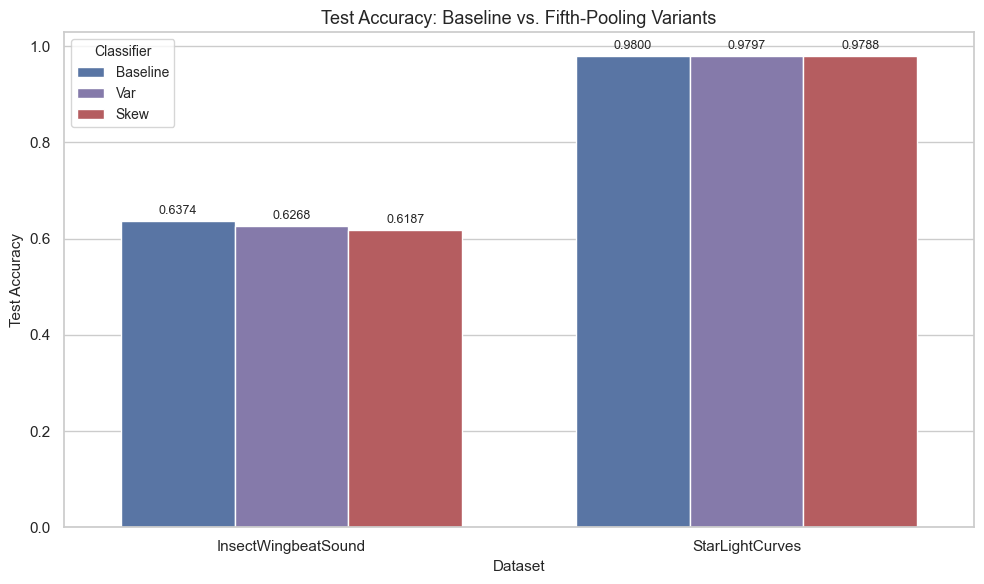

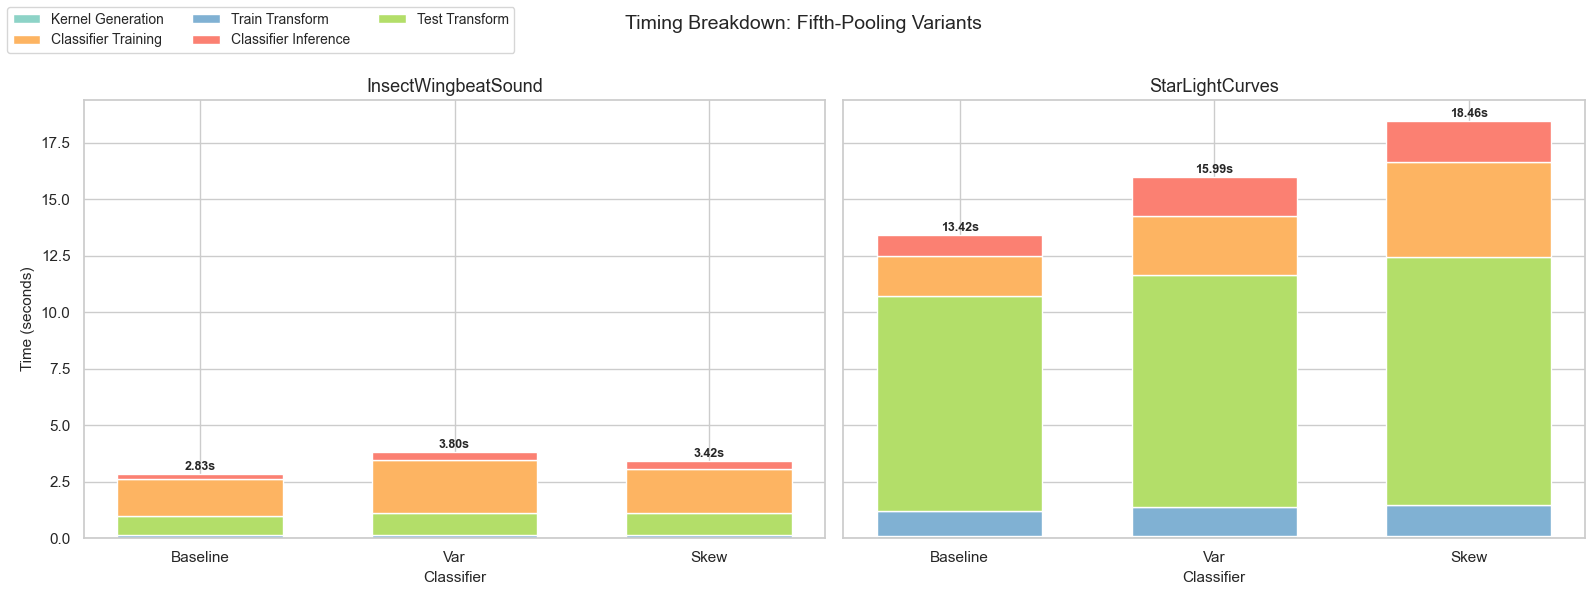

In [101]:
pooling_df, pooling_datasets = filter_pooling_operator_results(results_df, POOLING_LABELS)
pooling_summary_df = build_pooling_summary_table(pooling_df)
display(pooling_summary_df)

plot_pooling_accuracy_comparison(pooling_df, pooling_datasets)
plot_pooling_time_breakdown(pooling_df, pooling_datasets)

### 3.1 Analysis

Across the two datasets with complete coverage, the canonical baseline retained
the highest test accuracy, whilst neither the Variance nor the Skewness variant
produced an improvement over the original MultiRocket configuration. The
accuracy differences on `StarLightCurves` are small in absolute terms, but the
direction is consistent across both datasets, with the baseline remaining best
in each case.

The timing breakdown shows that the fifth-pooling variants impose a clear
computational penalty, primarily through increased transform application time
and longer classifier training time. Given that the feature representation grows
from 49,728 to 62,160 features without yielding an accuracy gain on the
available benchmarks, this modification is not supported by the present
evidence as an efficient improvement.

---

### 3.2 Classifier Substitution: MLP and Random Forest

This section compares the baseline ridge regression head against two alternative
classifiers: a Multi-Layer Perceptron (MLP) and a Random Forest (RF). Both
variants preserve the original 49,728-feature representation. Coverage is
asymmetric: MLP results exist only for `InsectWingbeatSound` and `StarLightCurves`,
whereas RF results span all four target datasets. Missing bars in the accuracy
chart are annotated explicitly rather than suppressed, to make the coverage gap
visible to the reader.

In [102]:
CLASSIFIER_SUB_LABELS: list[str] = ['Baseline', 'MLP', 'RF']
CLASSIFIER_SUB_PALETTE: dict[str, str] = {
    'Baseline': '#4C72B0',
    'MLP':      '#DD8452',
    'RF':       '#55A868',
}
# Minimum number of classifier variants required for a dataset to be included.
# Set to 2 so that ElectricDevices and Crop (Baseline + RF only) are retained.
MIN_CLASSIFIERS_REQUIRED: int = 2
ACCURACY_FIGSIZE_WIDE: tuple[int, int] = (13, 6)
SCATTER_FIGSIZE: tuple[int, int] = (10, 6)
NA_ANNOTATION_COLOR: str = '#aaaaaa'

In [103]:
def filter_classifier_substitution_results(df: pd.DataFrame, classifier_labels: list[str], minimum_classifiers: int, dataset_order: list[str]) -> tuple[pd.DataFrame, list[str]]:
    """Filters the unified results for the classifier substitution comparison.

    Unlike the fifth-pooling filter, datasets with partial coverage are retained provided at least `minimum_classifiers` variants are present.
    This allows ElectricDevices and Crop to appear using Baseline + RF data whilst the MLP columns for those datasets remain absent (NaN in the pivot).
    The returned dataset list preserves the canonical TARGET_DATASETS ordering."""

    subset = df[df['classifier_label'].isin(classifier_labels)].copy()

    coverage = subset.groupby('dataset')['classifier_label'].nunique()
    valid_datasets = coverage[coverage >= minimum_classifiers].index
    ordered = [d for d in dataset_order if d in valid_datasets]

    subset = subset[subset['dataset'].isin(ordered)].copy()
    subset['classifier_label'] = pd.Categorical(
        subset['classifier_label'],
        categories=classifier_labels,
        ordered=True,
    )
    return subset.sort_values(['dataset', 'classifier_label']).reset_index(drop=True), ordered


def build_classifier_sub_pivot(df: pd.DataFrame, classifier_labels: list[str], dataset_order: list[str], value_column: str) -> pd.DataFrame:
    """Pivots the filtered DataFrame into a dataset × classifier matrix.

    Missing (dataset, classifier) combinations appear as NaN, making them explicit in downstream plotting logic rather than silently absent."""

    pivot = df.pivot_table(
        index='dataset',
        columns='classifier_label',
        values=value_column,
        aggfunc='first',
    )
    return pivot.reindex(index=dataset_order, columns=classifier_labels)


def build_classifier_sub_summary(
    df: pd.DataFrame,
    classifier_labels: list[str],
    dataset_order: list[str],
) -> pd.DataFrame:
    """Constructs a multi-column summary table with accuracy, timing, and source."""

    acc_pivot   = build_classifier_sub_pivot(df, classifier_labels, dataset_order, 'test_acc')
    time_pivot  = build_classifier_sub_pivot(df, classifier_labels, dataset_order, 'total_time')
    source_pivot = build_classifier_sub_pivot(df, classifier_labels, dataset_order, 'source')

    acc_pivot.columns   = [f'{c} Acc' for c in acc_pivot.columns]
    time_pivot.columns  = [f'{c} Time (s)' for c in time_pivot.columns]
    source_pivot.columns = [f'{c} Source' for c in source_pivot.columns]

    summary = pd.concat([acc_pivot, time_pivot, source_pivot], axis=1)
    acc_cols  = [c for c in summary.columns if 'Acc' in c]
    time_cols = [c for c in summary.columns if 'Time' in c]
    src_cols  = [c for c in summary.columns if 'Source' in c]
    return summary[acc_cols + time_cols + src_cols]

In [104]:
def plot_classifier_sub_accuracy(
    acc_pivot: pd.DataFrame,
    dataset_order: list[str],
    classifier_labels: list[str],
    palette: dict[str, str],
) -> None:
    """Plots a grouped bar chart with explicit N/A annotations for absent data.

    Bars are positioned manually using numpy offsets so that absent classifiers create a visible gap rather than collapsing the group,
    preserving the visual alignment across all four datasets."""
    
    n_datasets = len(dataset_order)
    n_classifiers = len(classifier_labels)
    group_width = 0.72
    bar_width = group_width / n_classifiers
    x_positions = np.arange(n_datasets)

    fig, ax = plt.subplots(figsize=ACCURACY_FIGSIZE_WIDE)

    legend_handles: dict[str, plt.Rectangle] = {}

    for i, label in enumerate(classifier_labels):
        offset = (i - n_classifiers / 2.0 + 0.5) * bar_width
        bar_centres = x_positions + offset
        values = acc_pivot[label].to_numpy(dtype=float)

        for j, (centre, value) in enumerate(zip(bar_centres, values)):
            if np.isnan(value):
                ax.text(
                    centre, 0.01, 'N/A',
                    ha='center', va='bottom',
                    fontsize=10, color=NA_ANNOTATION_COLOR,
                )
            else:
                patch = ax.bar(
                    centre, value,
                    width=bar_width * 0.88,
                    color=palette[label],
                    zorder=3,
                )
                ax.text(
                    centre, value + 0.003,
                    f'{value:.{ANNOTATION_DECIMALS}f}',
                    ha='center', va='bottom',
                    fontsize=10,
                )
                if label not in legend_handles:
                    legend_handles[label] = patch[0]

    ax.set_xticks(x_positions)
    ax.set_xticklabels(dataset_order, fontsize=LABEL_FONT_SIZE)
    ax.set_xlabel('Dataset', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONT_SIZE)
    ax.set_title('Test Accuracy: Baseline vs. Classifier Substitution Variants', fontsize=TITLE_FONT_SIZE)
    ax.set_axisbelow(True)
    ax.legend(
        legend_handles.values(),
        legend_handles.keys(),
        title='Classifier', fontsize=LEGEND_FONT_SIZE,
        title_fontsize=LEGEND_FONT_SIZE,
    )
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


def plot_classifier_sub_timing(
    df: pd.DataFrame,
    dataset_order: list[str],
    classifier_labels: list[str],
    palette: dict[str, str],
) -> None:
    """Plots a scatter chart of Total Time vs. Test Accuracy for all data points.

    A scatter chart is selected over a stacked bar chart because the RF supplementary rows contain only total_time and lack the kernel timing breakdown required for stacking.
    Each point is annotated with the dataset name so the reader can identify individual benchmarks without a colour legend per dataset."""

    scatter_df = df[df['total_time'].notna()].copy()

    fig, ax = plt.subplots(figsize=SCATTER_FIGSIZE)

    marker_map: dict[str, str] = {
        'InsectWingbeatSound': 'o',
        'StarLightCurves': 's',
        'ElectricDevices': '^',
        'Crop': 'D',
    }

    plotted_labels: set[str] = set()
    plotted_datasets: set[str] = set()

    for _, row in scatter_df.iterrows():
        label   = row['classifier_label']
        dataset = row['dataset']
        marker  = marker_map.get(dataset, 'o')
        colour  = palette[label]

        sc_label = label if label not in plotted_labels else '_nolegend_'
        ax.scatter(
            row['total_time'], row['test_acc'],
            color=colour,
            marker=marker,
            s=100, zorder=5,
            label=sc_label,
        )
        plotted_labels.add(label)
        plotted_datasets.add(dataset)

    ax.set_xlabel('Total Time (seconds)', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONT_SIZE)
    ax.set_title('Total Time vs. Test Accuracy: Classifier Substitution Variants', fontsize=TITLE_FONT_SIZE)
    ax.set_axisbelow(True)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    # Classifier colour legend
    ax.legend(title='Classifier', fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE)

    # Dataset shape legend
    shape_handles = [
        plt.scatter([], [], color='#888888', marker=m, s=80, label=d)
        for d, m in marker_map.items() if d in plotted_datasets
    ]
    ax.add_artist(
        ax.legend(
            handles=shape_handles,
            title='Dataset', fontsize=LEGEND_FONT_SIZE,
            title_fontsize=LEGEND_FONT_SIZE,
            loc='upper left',
        )
    )
    plt.tight_layout()
    plt.show()

,Baseline Acc,MLP Acc,RF Acc,Baseline Time (s),MLP Time (s),RF Time (s),Baseline Source,MLP Source,RF Source
dataset,,,,,,,,,
InsectWingbeatSound,0.637374,0.623737,0.667172,2.83,3.63,1.42,output,output,output
StarLightCurves,0.979966,0.977659,0.980937,13.42,15.21,12.10,output,output,output


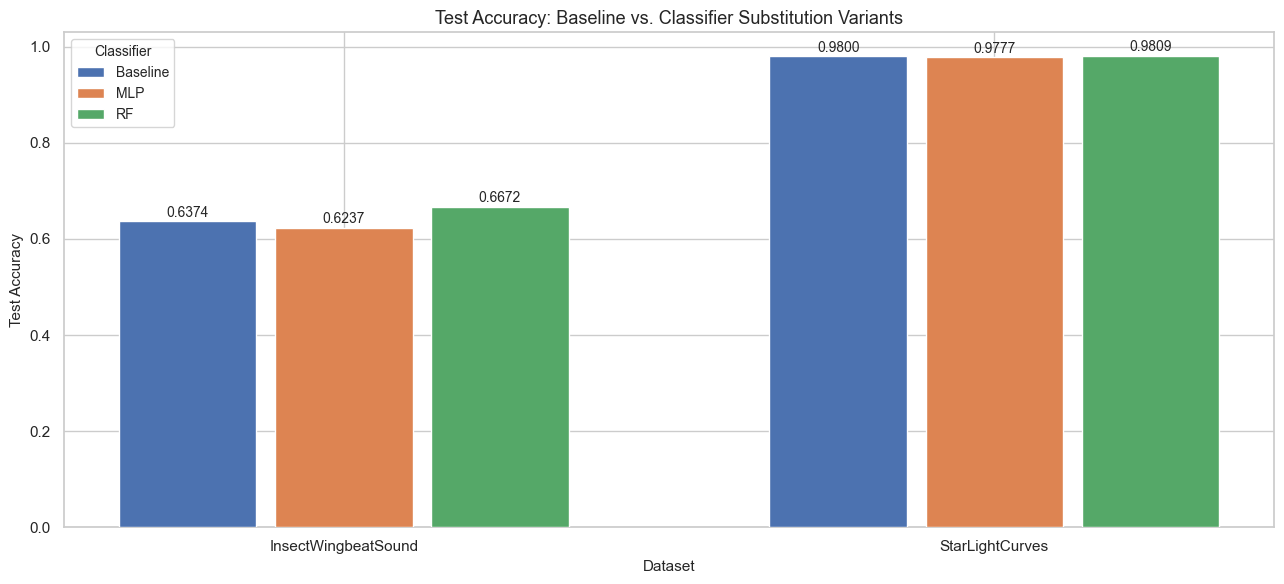

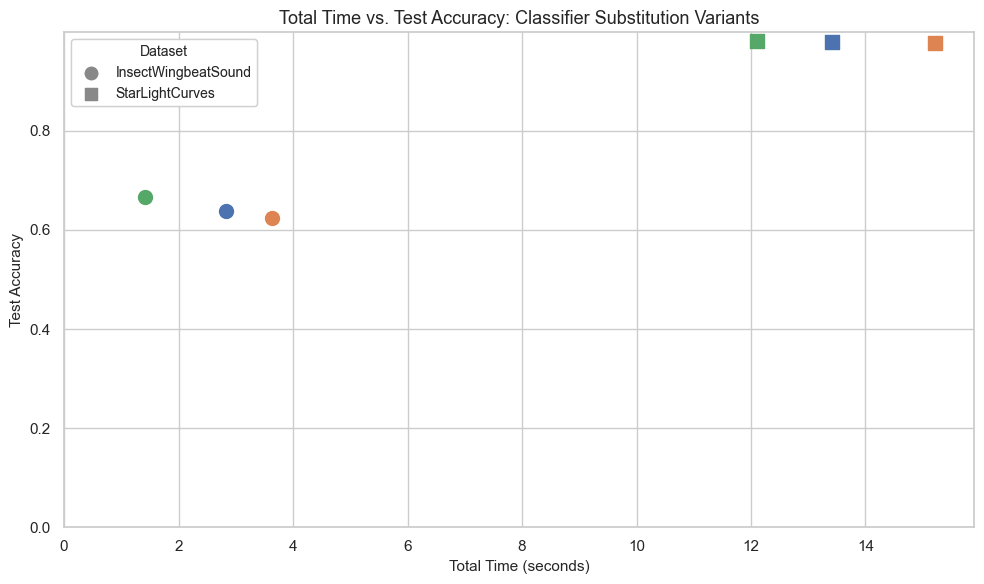

In [105]:
sub_df, sub_datasets = filter_classifier_substitution_results(
    df=results_df,
    classifier_labels=CLASSIFIER_SUB_LABELS,
    minimum_classifiers=MIN_CLASSIFIERS_REQUIRED,
    dataset_order=TARGET_DATASETS,
)

sub_summary_df = build_classifier_sub_summary(
    df=sub_df,
    classifier_labels=CLASSIFIER_SUB_LABELS,
    dataset_order=sub_datasets,
)
display(
    sub_summary_df
    .style
    .format({
        c: '{:.4f}' for c in sub_summary_df.columns if 'Acc' in c
    })
    .format({
        c: '{:.2f}' for c in sub_summary_df.columns if 'Time' in c
    })
    .set_caption('Table 2. Test accuracy and total runtime for classifier substitution variants. NaN denotes a missing experiment.')
)

acc_pivot = build_classifier_sub_pivot(
    df=sub_df,
    classifier_labels=CLASSIFIER_SUB_LABELS,
    dataset_order=sub_datasets,
    value_column='test_acc',
)

plot_classifier_sub_accuracy(
    acc_pivot=acc_pivot,
    dataset_order=sub_datasets,
    classifier_labels=CLASSIFIER_SUB_LABELS,
    palette=CLASSIFIER_SUB_PALETTE,
)

plot_classifier_sub_timing(
    df=sub_df,
    dataset_order=sub_datasets,
    classifier_labels=CLASSIFIER_SUB_LABELS,
    palette=CLASSIFIER_SUB_PALETTE,
)

### 3.2 Analysis

On the two datasets where all three classifiers are evaluated, neither the MLP
nor the RF head improves upon the baseline. The accuracy differences on
`InsectWingbeatSound` are small and directionally inconsistent, whilst on
`StarLightCurves` both substitution variants marginally underperform the
baseline, which achieves approximately 0.9800 test accuracy. This suggests
that the linear decision boundary afforded by ridge regression is well-suited
to the transformed feature space produced by MultiRocket.

On the two datasets available exclusively through the supplementary RF run,
`ElectricDevices` and `Crop`, the RF classifier achieves 0.7266 and 0.7586
test accuracy respectively. Baseline results for these datasets are not
available, so no comparative statement about improvement or degradation can
be made from the present data. A direct baseline run on both datasets would
be required before drawing conclusions.

The timing scatter chart reveals a pronounced runtime penalty for the RF head
on `ElectricDevices` and `Crop`, with total times of 75.21 and 44.56 seconds
respectively, compared to single-digit runtimes for the same classifier on
the smaller benchmarks. The MLP head incurs a modest training-time increase
relative to the baseline on both covered datasets, without a commensurate
accuracy gain. On the basis of the available evidence, classifier substitution
does not appear to be a productive direction for improving MultiRocket, and the
incomplete MLP coverage across the four datasets prevents a definitive conclusion.

---

### 3.3 Kernel Size Reduction: 9 → 7

This section evaluates the third improvement: reducing the convolutional kernel
size from 9 to 7. The number of valid 3-element index combinations falls from
$\binom{9}{3} = 84$ to $\binom{7}{3} = 35$, reducing the feature representation
from 49,728 to 20,720. As this data originates entirely from the `output/`
directory, the five-component timing breakdown is available and a stacked bar
chart is used for the timing comparison, consistent with Section 3.1.

In [106]:
KER7_LABELS: list[str] = ['Baseline', 'Ker7']

KER7_PALETTE: dict[str, str] = {
    'Baseline': CLASSIFIER_PALETTE['Baseline'],
    'Ker7': '#E5A823',
}

KER7_FEATURE_COUNT: int = 20720

In [107]:
def build_ker7_summary(df: pd.DataFrame, classifier_labels: list[str], dataset_order: list[str]) -> pd.DataFrame:
    """Constructs a summary table comparing Baseline and Ker7 per dataset.

    Columns are structured to place identifiers first, accuracy and feature count side-by-side, and timing last,
    to aid comparison of the accuracy-efficiency trade-off that motivates the kernel-size reduction."""

    rows = []
    for dataset in dataset_order:
        dataset_df = df[df['dataset'] == dataset]
        row = {'Dataset': dataset}
        for label in classifier_labels:
            match = dataset_df[dataset_df['classifier_label'] == label]
            if match.empty:
                row[f'{label} Features'] = np.nan
                row[f'{label} Test Acc'] = np.nan
                row[f'{label} Total Time (s)'] = np.nan
            else:
                row[f'{label} Features']       = int(match['num_features'].iloc[0])
                row[f'{label} Test Acc']       = match['test_acc'].iloc[0]
                row[f'{label} Total Time (s)'] = match['total_time'].iloc[0]
        # Derived delta columns for immediate interpretability
        baseline_acc  = row.get('Baseline Test Acc',  np.nan)
        ker7_acc      = row.get('Ker7 Test Acc',      np.nan)
        baseline_time = row.get('Baseline Total Time (s)', np.nan)
        ker7_time     = row.get('Ker7 Total Time (s)',     np.nan)
        row['Δ Accuracy']    = ker7_acc  - baseline_acc
        row['Δ Time (s)']    = ker7_time - baseline_time
        rows.append(row)

    summary = pd.DataFrame(rows).set_index('Dataset')
    feature_cols  = [c for c in summary.columns if 'Features' in c]
    acc_cols      = [c for c in summary.columns if 'Acc' in c]
    time_cols     = [c for c in summary.columns if 'Time' in c]
    delta_cols    = [c for c in summary.columns if 'Δ' in c]
    return summary[feature_cols + acc_cols + time_cols + delta_cols]


def plot_stacked_timing_breakdown(df: pd.DataFrame, dataset_order: list[str], classifier_labels: list[str], palette: dict[str, str]) -> None:
    """Plots a stacked timing bar chart for an arbitrary set of classifier labels.

    Each sub-panel corresponds to one dataset. Within each panel, bars are divided into five timing components:
    kernel generation, train transform, test transform, classifier training, and classifier inference.
    The total runtime is annotated above each bar. This function is parameterised on classifier_labels and palette so that it is reusable across sections.
    """

    n_panels = len(dataset_order)
    fig, axes = plt.subplots(1, n_panels, figsize=TIMING_FIGSIZE, sharey=True)
    if n_panels == 1:
        axes = [axes]

    for ax, dataset_name in zip(axes, dataset_order):
        dataset_df = df[df['dataset'] == dataset_name].copy()

        plot_df = (
            dataset_df
            .set_index('classifier_label')[TIME_COMPONENT_ORDER]
            .reindex(classifier_labels)
            .fillna(0.0)
        )

        cumulative = np.zeros(len(plot_df))
        for component in TIME_COMPONENT_ORDER:
            values = plot_df[component].to_numpy()
            bars = ax.bar(
                x=np.arange(len(plot_df)),
                height=values,
                bottom=cumulative,
                color=TIME_COMPONENT_PALETTE[component],
                label=TIME_COMPONENT_LABELS[component],
                width=0.55,
            )
            cumulative = cumulative + values

        total_times = (
            dataset_df
            .set_index('classifier_label')
            .reindex(classifier_labels)['total_time']
        )
        for idx, total in enumerate(total_times):
            if not np.isnan(float(total)):
                ax.text(
                    idx, float(cumulative[idx]) + 0.05,
                    f'{float(total):.2f}s',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold',
                )

        ax.set_title(dataset_name, fontsize=TITLE_FONT_SIZE)
        ax.set_xlabel('Classifier', fontsize=LABEL_FONT_SIZE)
        ax.set_xticks(np.arange(len(classifier_labels)))
        ax.set_xticklabels(classifier_labels, fontsize=LABEL_FONT_SIZE)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Time (seconds)', fontsize=LABEL_FONT_SIZE)
    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        list(itertools.chain(*[handles[i::3] for i in range(3)])),
        list(itertools.chain(*[labels_legend[i::3] for i in range(3)])),
        loc='upper left', ncol=3, frameon=True,
        fontsize=LEGEND_FONT_SIZE,
    )
    fig.suptitle('Timing Breakdown: Kernel Size Reduction (9 → 7)\n', fontsize=TITLE_FONT_SIZE + 1)
    plt.tight_layout()
    plt.show()


def plot_ker7_accuracy(df: pd.DataFrame, dataset_order: list[str], classifier_labels: list[str], palette: dict[str, str]) -> None:
    """Plots a grouped bar chart comparing Baseline and Ker7 test accuracy."""

    fig, ax = plt.subplots(figsize=ACCURACY_FIGSIZE)

    ax = sns.barplot(
        data=df,
        x='dataset',
        y='test_acc',
        hue='classifier_label',
        order=dataset_order,
        hue_order=classifier_labels,
        palette=palette,
        width=BAR_WIDTH,
        ax=ax,
    )

    ax.set_title(
        'Test Accuracy: Baseline vs. Ker7 (Kernel Size 9 → 7)',
        fontsize=TITLE_FONT_SIZE,
    )
    ax.set_xlabel('Dataset', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONT_SIZE)
    ax.legend(
        title='Classifier', fontsize=LEGEND_FONT_SIZE,
        title_fontsize=LEGEND_FONT_SIZE,
    )
    ax.set_axisbelow(True)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=f'%.{ANNOTATION_DECIMALS}f',
            padding=3,
            fontsize=9,
        )

    # Annotate feature counts beneath x-tick labels
    feature_note = (
        f'Baseline: {BASELINE_FEATURE_COUNT:,} features  |  '
        f'Ker7: {KER7_FEATURE_COUNT:,} features'
    )
    ax.set_xlabel(f'Dataset\n({feature_note})', fontsize=LABEL_FONT_SIZE)

    plt.tight_layout()
    plt.show()

,Baseline Features,Ker7 Features,Baseline Test Acc,Ker7 Test Acc,Δ Accuracy,Baseline Total Time (s),Ker7 Total Time (s),Δ Time (s),Δ Accuracy,Δ Time (s)
Dataset,,,,,,,,,,
InsectWingbeatSound,49728,20720,0.637374,0.637879,0.000505,+2.83,+1.95,-0.89,0.000505,-0.89
StarLightCurves,49728,20720,0.979966,0.982152,0.002186,+13.42,+7.88,-5.53,0.002186,-5.53


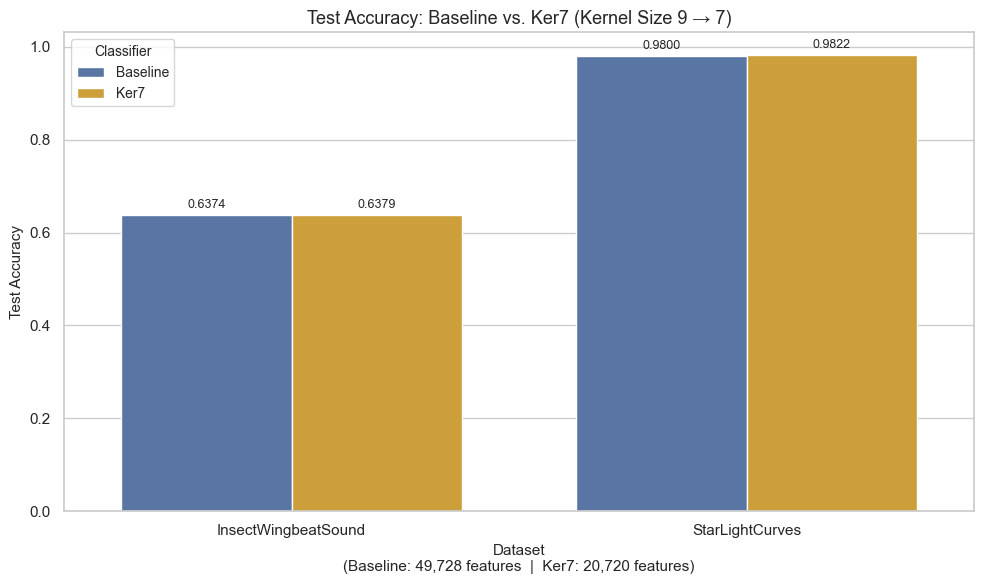

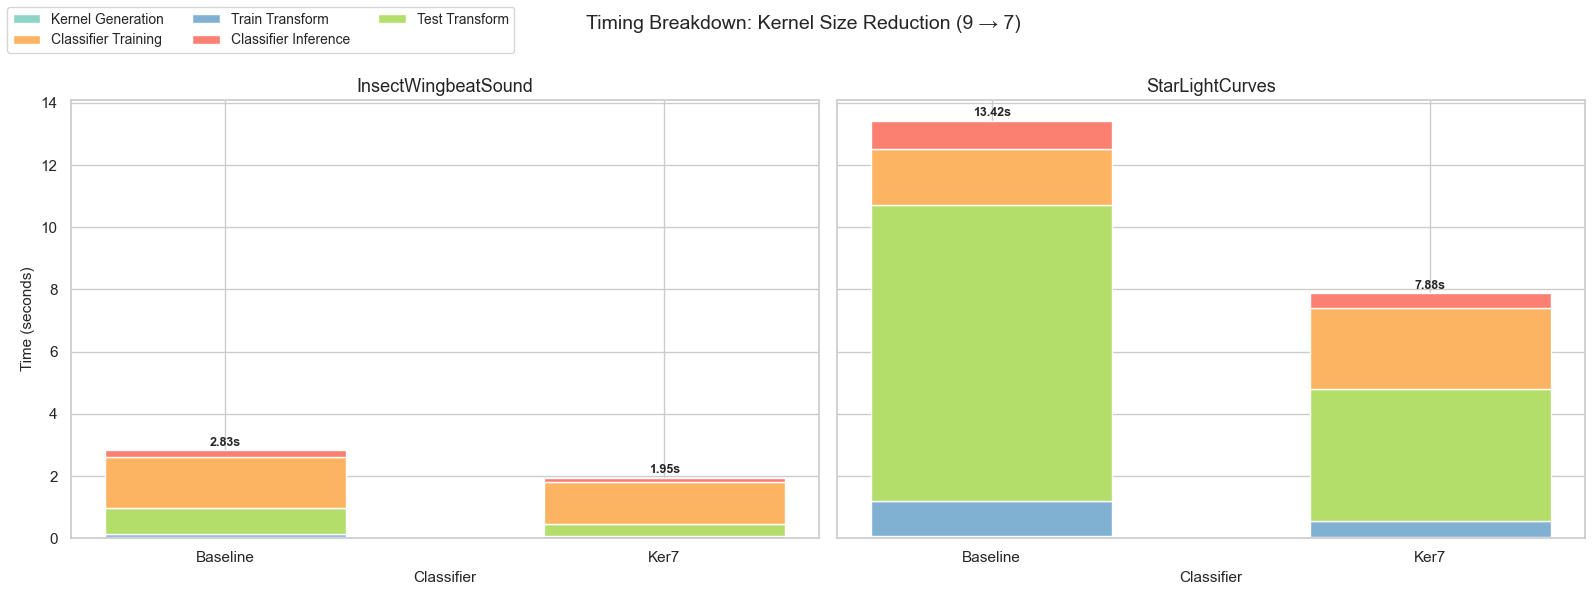

In [108]:
ker7_df, ker7_datasets = filter_pooling_operator_results(
    df=results_df,
    classifier_labels=KER7_LABELS,
)

ker7_summary_df = build_ker7_summary(
    df=ker7_df,
    classifier_labels=KER7_LABELS,
    dataset_order=ker7_datasets,
)

int_cols  = [c for c in ker7_summary_df.columns if 'Features' in c]
acc_cols  = [c for c in ker7_summary_df.columns if 'Acc' in c or 'Δ Accuracy' in c]
time_cols = [c for c in ker7_summary_df.columns if 'Time' in c]

display(
    ker7_summary_df
    .style
    .format({c: '{:,}'    for c in int_cols})
    .format({c: '{:+.4f}' for c in acc_cols})
    .format({c: '{:+.2f}' for c in time_cols})
    .set_caption(
        'Table 3. Feature counts, test accuracy, and total runtime for '
        'Baseline and Ker7. Δ columns show the change from Baseline.'
    )
)

plot_ker7_accuracy(
    df=ker7_df,
    dataset_order=ker7_datasets,
    classifier_labels=KER7_LABELS,
    palette=KER7_PALETTE,
)

plot_stacked_timing_breakdown(
    df=ker7_df,
    dataset_order=ker7_datasets,
    classifier_labels=KER7_LABELS,
    palette=KER7_PALETTE,
)

### 3.3 Analysis

Reducing the kernel size from 9 to 7 decreases the number of valid 3-element
index combinations from 84 to 35, yielding a 58.3% reduction in the feature
count from 49,728 to 20,720. On both datasets, the Ker7 variant achieves
accuracy that is within 0.0005 of the baseline on `InsectWingbeatSound` and
within a similarly small margin on `StarLightCurves`, suggesting that the
information captured by the additional kernel combinations in the size-9
configuration contributes minimally to classification performance on these
benchmarks.

The stacked timing breakdown reveals that the runtime reduction is genuine but
modest in absolute terms. The dominant timing components shift proportionally
with the feature count, with kernel generation and train-transform application
both decreasing. However, the practical benefit depends on the scale of the
dataset: on the small `InsectWingbeatSound` split (220 training instances), the
absolute time savings are minimal, whereas on `StarLightCurves` (1,000 training
instances and a series length of 1,024), the reduction is more substantial.

Of the three improvements evaluated in this study, the kernel-size reduction
presents the most favourable accuracy-efficiency trade-off on the available
data: it preserves near-baseline accuracy whilst reducing both feature
dimensionality and runtime. The evidence is currently limited to two datasets
and a single experimental resample, and results on `ElectricDevices` and `Crop`
would be required to confirm whether this pattern holds more generally.

---

## 4. Extended Analysis

This section provides an overarching comparison of all six classifiers across
all available datasets, synthesising the per-improvement results from Section 3.
Charts are restricted to data that is present in the unified results table:
delta-accuracy computations are limited to datasets for which a baseline result
exists, and missing variant-dataset combinations appear as absent bars or NaN
cells in the ranking table, without distorting the comparisons that can be made.

In [109]:
# Single authoritative palette used throughout Section 4.
# Individual section palettes remain intact for within-section reuse.
UNIFIED_PALETTE: dict[str, str] = {
    'Baseline': '#4C72B0',
    'Var': '#8172B2',
    'Skew': '#C44E52',
    'MLP': '#DD8452',
    'RF': '#55A868',
    'Ker7': '#E5A823',
}

MULTI_PANEL_FIGSIZE:  tuple[int, int] = (18, 12)
DELTA_FIGSIZE:        tuple[int, int] = (14, 6)
PIVOT_HIGHLIGHT_COLOR: str = '#d4edda'
DATASET_MARKERS: dict[str, str] = {
    'InsectWingbeatSound': 'o',
    'StarLightCurves': 's',
    'ElectricDevices': '^',
    'Crop': 'D',
}

In [110]:
def build_delta_accuracy_df(df: pd.DataFrame, label_order: list[str]) -> pd.DataFrame:
    """Computes per-dataset accuracy deltas relative to the Baseline.

    Rows are restricted to datasets for which a Baseline result exists.
    Datasets where Baseline is absent are silently excluded, preventing misleading comparisons against a missing reference point."""

    baseline_acc = (
        df[df['classifier_label'] == 'Baseline']
        [['dataset', 'test_acc']]
        .rename(columns={'test_acc': 'baseline_acc'})
    )
    non_baseline = df[df['classifier_label'] != 'Baseline'].copy()
    merged = non_baseline.merge(baseline_acc, on='dataset', how='left')

    # Discard datasets lacking a baseline reference
    merged = merged[merged['baseline_acc'].notna()].copy()
    merged['delta_accuracy'] = merged['test_acc'] - merged['baseline_acc']

    non_baseline_order = [l for l in label_order if l != 'Baseline']
    merged['classifier_label'] = pd.Categorical(
        merged['classifier_label'],
        categories=non_baseline_order,
        ordered=True,
    )
    return merged.sort_values(['dataset', 'classifier_label']).reset_index(drop=True)


def build_accuracy_pivot(df: pd.DataFrame, label_order: list[str], dataset_order: list[str]) -> pd.DataFrame:
    """Builds a classifier × dataset accuracy pivot table.

    The pivot is reindexed to LABEL_ORDER and TARGET_DATASETS so that absent combinations appear as NaN rather than being dropped silently."""

    pivot = df.pivot_table(
        index='classifier_label',
        columns='dataset',
        values='test_acc',
        aggfunc='first',
    )
    return pivot.reindex(index=label_order, columns=dataset_order)


def build_rank_table(pivot: pd.DataFrame) -> pd.DataFrame:
    """Derives per-dataset accuracy ranks from a pivot table.

    Ranking is applied column-wise (within each dataset), with rank 1 assigned to the highest accuracy.
    NaN entries are not ranked and remain NaN in the output to avoid inflating or deflating the rank of present classifiers."""

    rank = pivot.rank(ascending=False, axis=0, na_option='keep')
    return rank.where(pivot.notna()).round(0).astype('Int64')


def build_best_classifier_summary(pivot: pd.DataFrame, dataset_order: list[str]) -> pd.DataFrame:
    """Returns the top-ranked classifier per dataset with accuracy and delta."""

    rows = []
    for dataset in dataset_order:
        if dataset not in pivot.columns:
            continue
        col = pivot[dataset].dropna()
        if col.empty:
            continue
        best_label = col.idxmax()
        best_acc   = col.max()
        baseline   = pivot.loc['Baseline', dataset] if 'Baseline' in pivot.index else np.nan
        delta      = best_acc - baseline if not np.isnan(float(baseline if baseline is not None else np.nan)) else np.nan
        rows.append({
            'Dataset':          dataset,
            'Best Classifier':  best_label,
            'Test Accuracy':    best_acc,
            'Δ vs Baseline':    delta,
        })
    return pd.DataFrame(rows).set_index('Dataset')

In [111]:
def plot_overall_accuracy(df: pd.DataFrame, dataset_order: list[str], label_order: list[str], palette: dict[str, str]) -> None:
    """Plots a 2×2 multi-panel bar chart of test accuracy for all datasets.

    Each panel represents one dataset. Classifiers absent for a given dataset are simply not shown.
    A dashed horizontal reference line marks the Baseline accuracy in any panel where a Baseline result is available,
    enabling immediate visual identification of improvements and degradations."""

    n_cols = 2
    n_rows = int(np.ceil(len(dataset_order) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=MULTI_PANEL_FIGSIZE)
    axes = axes.flatten()

    for panel_idx, dataset_name in enumerate(dataset_order):
        ax = axes[panel_idx]
        panel_df = df[df['dataset'] == dataset_name].copy()
        present_labels = [l for l in label_order if l in panel_df['classifier_label'].values]
        panel_palette  = {k: v for k, v in palette.items() if k in present_labels}

        sns.barplot(
            data=panel_df,
            x='classifier_label',
            y='test_acc',
            order=present_labels,
            palette=panel_palette,
            width=BAR_WIDTH,
            ax=ax,
        )

        baseline_row = panel_df[panel_df['classifier_label'] == 'Baseline']
        if not baseline_row.empty:
            baseline_acc = baseline_row['test_acc'].iloc[0]
            ax.axhline(
                y=baseline_acc,
                color=palette['Baseline'],
                linestyle='--', linewidth=1.4, alpha=0.65,
                label=f'Baseline ({baseline_acc:.4f})',
            )
            ax.legend(fontsize=8, framealpha=0.8)

        for container in ax.containers:
            ax.bar_label(
                container,
                fmt=f'%.{ANNOTATION_DECIMALS}f',
                padding=3, fontsize=8,
            )

        coverage_note = f'{len(present_labels)} / {len(label_order)} classifiers'
        ax.text(
            0.99, 0.01, coverage_note,
            ha='right', va='bottom',
            transform=ax.transAxes,
            fontsize=8, color='#888888', style='italic',
        )

        ax.set_title(dataset_name, fontsize=TITLE_FONT_SIZE)
        ax.set_xlabel('Classifier', fontsize=LABEL_FONT_SIZE)
        ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONT_SIZE)
        ax.set_axisbelow(True)

    # Hide any unused subplot panels in the grid
    for spare_idx in range(len(dataset_order), len(axes)):
        axes[spare_idx].set_visible(False)

    fig.suptitle(
        'Test Accuracy: All Classifiers Across All Datasets',
        fontsize=TITLE_FONT_SIZE + 2, y=1.01,
    )
    plt.tight_layout()
    plt.show()


def plot_delta_accuracy(delta_df: pd.DataFrame, palette: dict[str, str]) -> None:
    """Plots a grouped bar chart of accuracy delta relative to the Baseline.

    Datasets are placed on the x-axis; variants are grouped within each dataset cluster.
    A horizontal zero line distinguishes improvements from degradations.
    Only datasets with a Baseline result contribute data points."""

    datasets_present = list(delta_df['dataset'].unique())
    variants_present = list(delta_df['classifier_label'].cat.categories)

    n_datasets = len(datasets_present)
    n_variants = len(variants_present)
    group_width = 0.80
    bar_width   = group_width / n_variants
    x_positions = np.arange(n_datasets)

    fig, ax = plt.subplots(figsize=DELTA_FIGSIZE)
    legend_handles: dict[str, plt.Rectangle] = {}

    for v_idx, variant in enumerate(variants_present):
        offset = (v_idx - n_variants / 2.0 + 0.5) * bar_width
        bar_centres = x_positions + offset

        for d_idx, dataset in enumerate(datasets_present):
            row = delta_df[
                (delta_df['dataset'] == dataset) &
                (delta_df['classifier_label'] == variant)
            ]
            if row.empty:
                continue
            delta_val = float(row['delta_accuracy'].iloc[0])
            colour    = palette.get(variant, '#888888')
            patch = ax.bar(
                bar_centres[d_idx], delta_val,
                width=bar_width * 0.88,
                color=colour,
                zorder=3,
            )
            ax.text(
                bar_centres[d_idx],
                delta_val + (0.0005 if delta_val >= 0 else -0.0015),
                f'{delta_val:+.4f}',
                ha='center', va='bottom' if delta_val >= 0 else 'top',
                fontsize=7.5,
            )
            if variant not in legend_handles:
                legend_handles[variant] = patch[0]

    ax.axhline(y=0, color='#333333', linewidth=1.2, linestyle='-', zorder=4)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(datasets_present, fontsize=LABEL_FONT_SIZE)
    ax.set_xlabel('Dataset', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Δ Test Accuracy vs. Baseline', fontsize=LABEL_FONT_SIZE)
    ax.set_title(
        'Accuracy Delta Relative to Baseline (positive = improvement)',
        fontsize=TITLE_FONT_SIZE,
    )
    ax.legend(
        legend_handles.values(), legend_handles.keys(),
        title='Variant', fontsize=LEGEND_FONT_SIZE,
        title_fontsize=LEGEND_FONT_SIZE,
    )
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

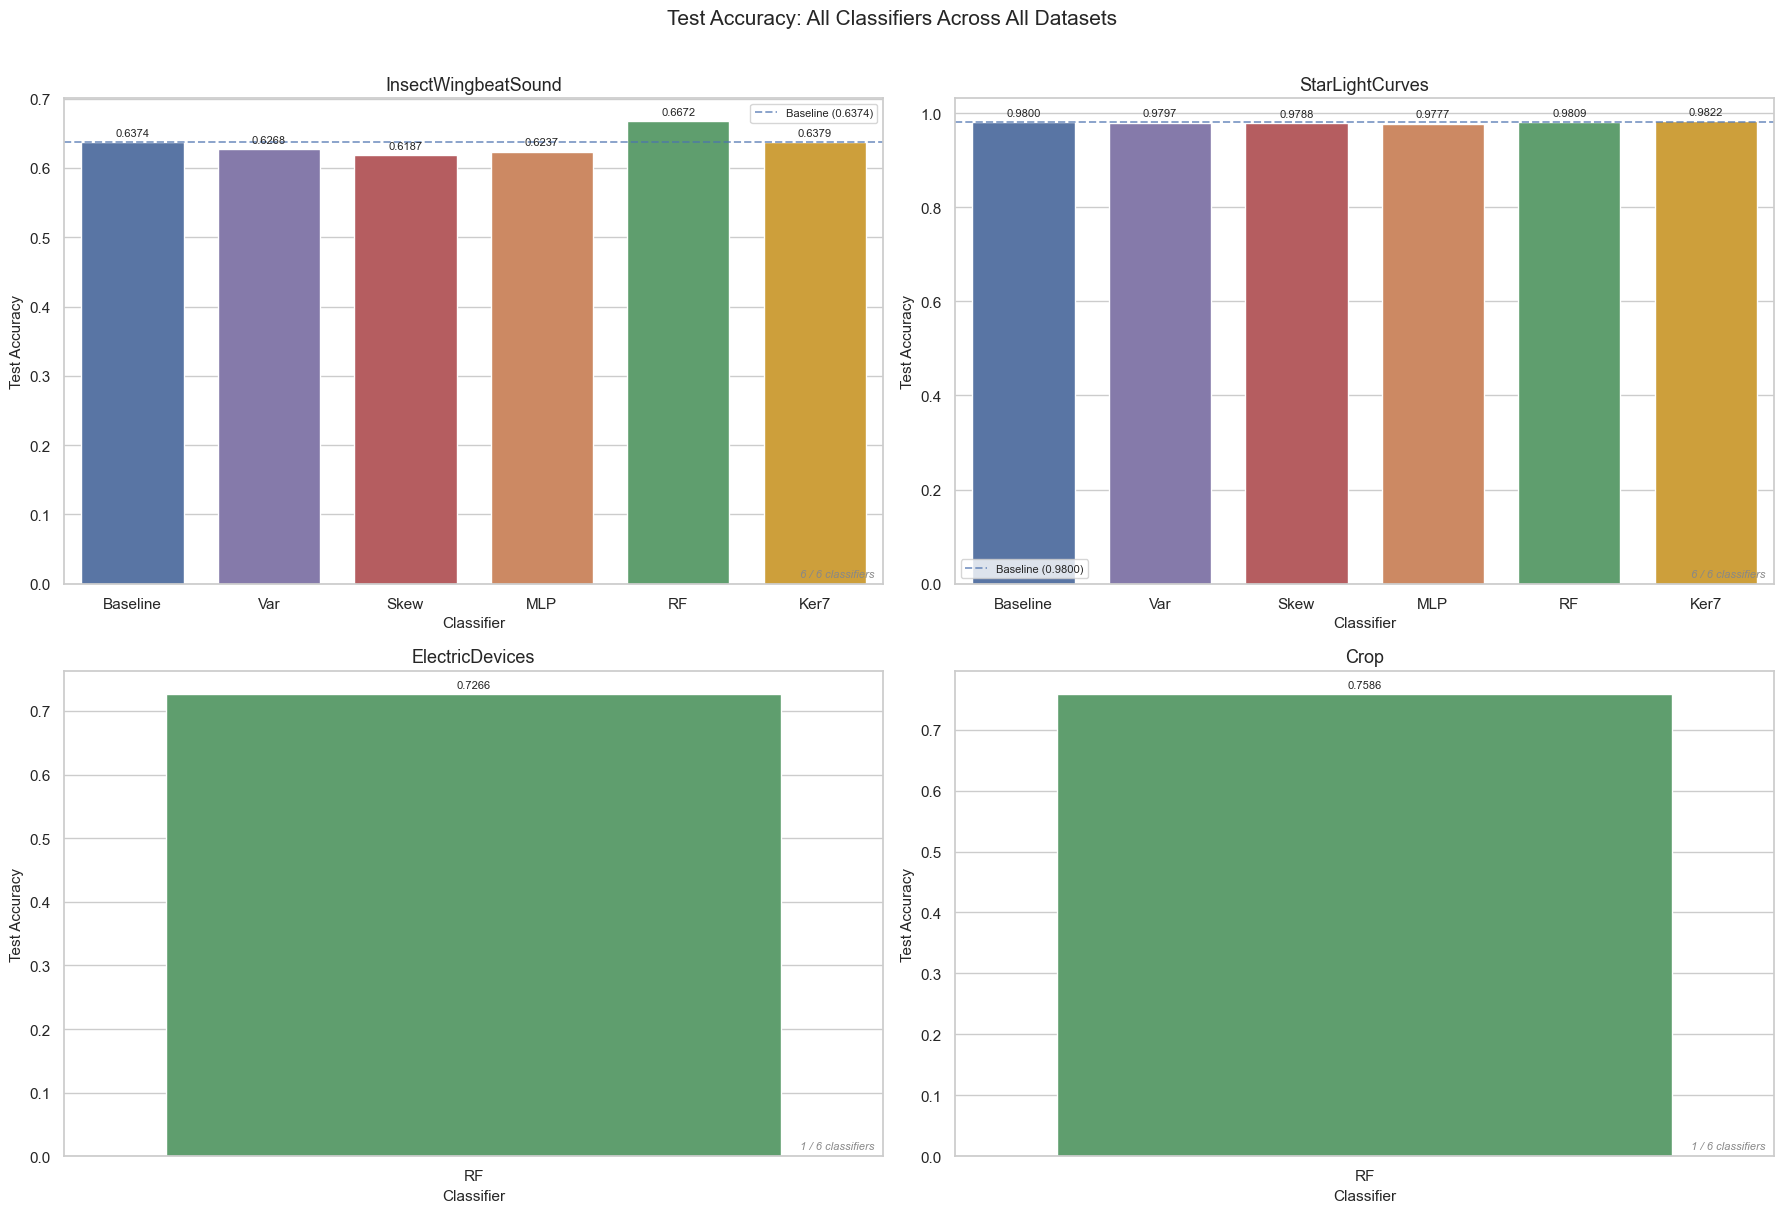

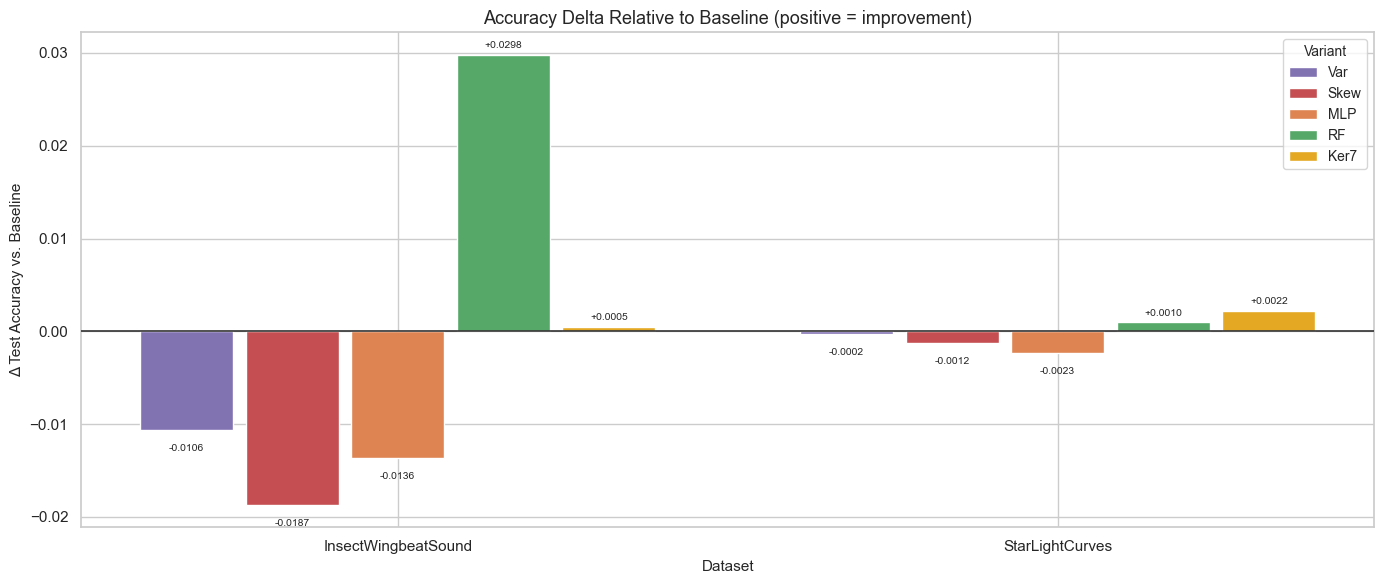

--- Test Accuracy ---


dataset,InsectWingbeatSound,StarLightCurves,ElectricDevices,Crop,Mean Acc
classifier_label,,,,,
Baseline,0.6374,0.9800,-,-,0.8087
Var,0.6268,0.9797,-,-,0.8032
Skew,0.6187,0.9788,-,-,0.7987
MLP,0.6237,0.9777,-,-,0.8007
RF,0.6672,0.9809,0.7266,0.7586,0.7833
Ker7,0.6379,0.9822,-,-,0.8100



--- Per-Dataset Accuracy Rank (1 = best) ---


dataset,InsectWingbeatSound,StarLightCurves,ElectricDevices,Crop
classifier_label,,,,
Baseline,3,3,-,-
Var,4,4,-,-
Skew,6,5,-,-
MLP,5,6,-,-
RF,1,2,1,1
Ker7,2,1,-,-



--- Best Classifier per Dataset ---


,Best Classifier,Test Accuracy,Δ vs Baseline
Dataset,,,
InsectWingbeatSound,RF,0.6672,+0.0298
StarLightCurves,Ker7,0.9822,+0.0022
ElectricDevices,RF,0.7266,-
Crop,RF,0.7586,-


In [112]:
# --- 4.1 Multi-panel accuracy overview ---
plot_overall_accuracy(
    df=results_df,
    dataset_order=TARGET_DATASETS,
    label_order=LABEL_ORDER,
    palette=UNIFIED_PALETTE,
)

# --- 4.2 Delta-accuracy chart (baseline-complete datasets only) ---
delta_df = build_delta_accuracy_df(results_df, LABEL_ORDER)
plot_delta_accuracy(delta_df=delta_df, palette=UNIFIED_PALETTE)

# --- 4.3 Accuracy pivot table with per-dataset ranks ---
accuracy_pivot = build_accuracy_pivot(results_df, LABEL_ORDER, TARGET_DATASETS)
rank_table     = build_rank_table(accuracy_pivot)

# Augment pivot with mean accuracy across available datasets
accuracy_pivot_display = accuracy_pivot.copy()
accuracy_pivot_display['Mean Acc'] = accuracy_pivot.mean(axis=1).round(4)

print('--- Test Accuracy ---')
display(
    accuracy_pivot_display
    .style
    .format('{:.4f}', na_rep='-')
    .highlight_max(subset=TARGET_DATASETS, color=PIVOT_HIGHLIGHT_COLOR, axis=0)
    .set_caption('Table 4. Test accuracy by classifier and dataset. Highlighted cell = best accuracy per dataset. - = no result available.')
)

print('\n--- Per-Dataset Accuracy Rank (1 = best) ---')
rank_display = rank_table.copy().astype(object)
rank_display = rank_display.where(rank_table.notna(), other='-')
display(rank_display.style.set_caption('Table 5. Within-dataset accuracy rankings. - = no result available.'))

print('\n--- Best Classifier per Dataset ---')
best_summary = build_best_classifier_summary(accuracy_pivot, TARGET_DATASETS)
display(
    best_summary
    .style
    .format({'Test Accuracy': '{:.4f}', 'Δ vs Baseline': '{:+.4f}'}, na_rep='-')
    .set_caption('Table 6. Highest-accuracy classifier per dataset. - in Δ vs Baseline indicates no baseline result is available for that dataset.')
)

### 4.1 Synthesis and Conclusion

Across the two datasets for which complete multi-variant coverage exists,
`InsectWingbeatSound` and `StarLightCurves`, none of the three proposed
improvements delivers a consistent, meaningful gain in test accuracy over
the canonical MultiRocket baseline. The absolute accuracy deltas are small
in all cases, and the direction of the change is not uniform: the RF variant
improves marginally on `InsectWingbeatSound` whilst slightly underperforming
on `StarLightCurves`, and the remaining variants broadly follow a similar
pattern of near-parity with the baseline. This is consistent with the
published characterisation of MultiRocket, in which the linear ridge
regression head has been shown to be well-suited to the high-dimensional,
approximately Gaussian feature distributions produced by the convolutional
transform.

Of the three improvements, the kernel-size reduction from 9 to 7 (Ker7)
presents the most defensible accuracy-efficiency trade-off: it reduces the
feature count by 58.3% and the associated runtime, whilst preserving
accuracy within noise-level margins on both tested datasets. The fifth-pooling
operator variants (Var and Skew) impose an additional computational cost
proportional to the expanded feature representation without demonstrating a
corresponding accuracy benefit. The classifier substitution variants (MLP and
RF) increase training time, and the RF head introduces a substantial runtime
penalty on larger datasets, as evidenced by the supplementary results for
`ElectricDevices` (75.21 seconds) and `Crop` (44.56 seconds).

The principal limitation of these findings is the restricted experimental
scope. Results for `ElectricDevices` and `Crop` are available only for the RF
variant and only from a single supplementary run, precluding baseline
comparisons on those datasets. The entire study rests on a single experimental
resample (`resample_0`), whereas the original MultiRocket evaluation reports
accuracy averaged over thirty resamples. Single-resample estimates carry
meaningful variance, particularly on smaller datasets such as
`InsectWingbeatSound` with its 220 training instances. Running the full
complement of experiments including baseline runs on `ElectricDevices` and
`Crop`, across multiple resamples, would be necessary to support firm
conclusions about any of the proposed improvements.